In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ModuleNotFoundError: No module named 'numpy'

In [6]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

ModuleNotFoundError: No module named 'torch'

In [ ]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []

    for label in LABELS:
        class_dir = DATA_DIR / label
        all_paths = list(class_dir.glob("*.jpg"))

        print(f"{label}: found {len(all_paths)} images")

        if len(all_paths) < n_per_class:
            print(f"Warning: only found {len(all_paths)} images for {label}")

        paths = random.sample(all_paths, min(n_per_class, len(all_paths)))

        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))

    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

buildings: found 437 images
forest: found 474 images
glacier: found 553 images
mountain: found 525 images
sea: found 510 images
street: found 501 images
Total images loaded: 60


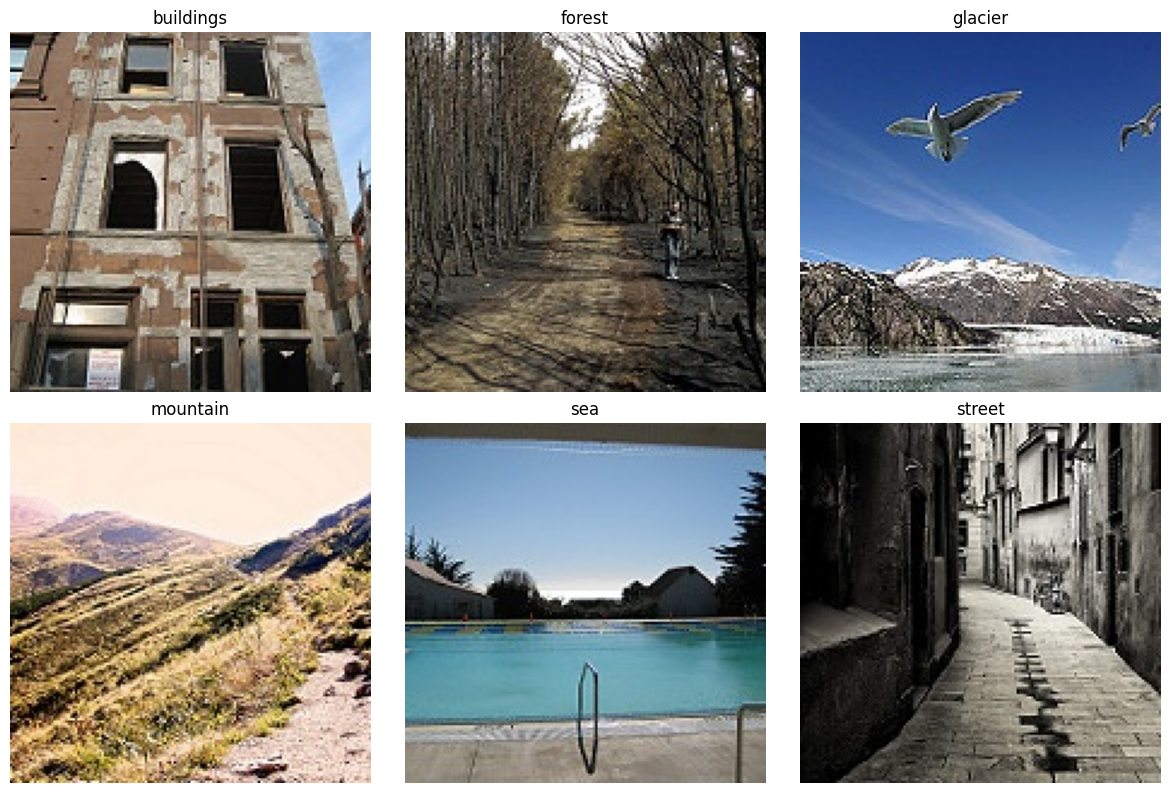

In [ ]:
# Display one sample image per class
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, label in enumerate(LABELS):
    sample_img = next(img for img, true_label in image_set if true_label == label)
    axes[i].imshow(sample_img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png", dpi=150)
plt.show()

The six scene types in this dataset are buildings, forest, glacier, mountain, sea, and street. The models used in this project were pretrained on ImageNet, whose 1,000 classes include labels like "alp", "lakeside", "valley", and "barn" rather than the exact six Intel scene labels.

This does not make pretrained ImageNet models a poor fit. They are still a reasonable starting point because ImageNet CNNs learn general visual features such as edges, textures, shapes, colors, object parts, and scene-like cues.
Even though the class labels do not directly match, many ImageNet categories overlap semantically with the Intel scenes. For example, "alp" may relate to mountains or glaciers, "lakeside" may relate to sea, and "barn" or buildings may relate to built environments.

However, the mismatch means the raw ImageNet predictions should not be treated as exact six-class predictions. The pretrained models can provide useful features and rough semantic signals, but for production classification on this dataset, fine-tuning or training a custom classifier head on the six target classes would likely perform better.

# Task 2: Baseline Inference with ResNet18

In [ ]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


ResNet18 parameters: 11,689,512


In [ ]:
def run_inference(model, preproc, pil_img, device, class_labels, top_k=5):
    """
    Run inference on one PIL image.

    Returns:
        List of (class_name, probability) tuples.
    """
    x = preproc(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)

    top_probs, top_idxs = torch.topk(probs, k=top_k, dim=1)

    results = []
    for prob, idx in zip(top_probs[0], top_idxs[0]):
        class_name = class_labels[idx.item()]
        probability = prob.item()
        results.append((class_name, probability))

    return results

In [ ]:
resnet_results = []

for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)

    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [ ]:
overall_mean = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean top-1 probability: {overall_mean:.4f}")

print("\nMean top-1 probability by true class:")
for label in LABELS:
    class_probs = [
        r["top1_prob"]
        for r in resnet_results
        if r["true_label"] == label
    ]
    print(f"{label:10s}: {np.mean(class_probs):.4f}")

Overall mean top-1 probability: 0.4195

Mean top-1 probability by true class:
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544


In [ ]:
boxplot_data = []

for label in LABELS:
    probs = [
        r["top1_prob"]
        for r in resnet_results
        if r["true_label"] == label
    ]
    boxplot_data.append(probs)

plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=LABELS)
plt.title("ResNet18 Top-1 Confidence by True Class")
plt.ylabel("Top-1 Probability")
plt.xlabel("True Class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/resnet18_confidence_by_class.png", dpi=150)
plt.show()

NameError: name 'LABELS' is not defined

High confidence and high accuracy are not the same thing. A model can be confidently wrong, especially when the ImageNet classes do not directly match the six Intel scene labels.

In a production image tagging pipeline, I would use confidence scores as a triage signal rather than as proof that the prediction is correct. For example, images with very high confidence could be automatically tagged, while images with low or uncertain confidence could be sent to a human reviewer.

A reasonable starting threshold might be something like 0.50 or 0.60 for automatic tagging. If the top-1 probability is below that threshold, or if the top two predictions are very close together, the image could be flagged for review. The exact threshold should be chosen by testing on validation data and balancing accuracy, review cost, and risk.

# Task 3: Multi-Model Comparison

In [ ]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 98.4MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


A smaller parameter count usually means the model has less capacity: fewer learned weights and generally less ability to represent complex patterns.
However, smaller models are often faster, use less memory, and require less compute.

For a phone or edge device, a smaller model like MobileNetV3-Small is often a better deployment choice because latency, battery use, and memory are major constraints. For a cloud server, a larger model may be acceptable if it gives better predictions, because the server usually has stronger hardware and can handle more computation.
The tradeoff is usually speed and efficiency versus accuracy and capacity.

In [ ]:
mobilenet_results = []

for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)

    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"MobileNet processed {len(mobilenet_results)} images.")

MobileNet processed 60 images.


In [ ]:
effnet_results = []

for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)

    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"EfficientNet processed {len(effnet_results)} images.")

EfficientNet processed 60 images.


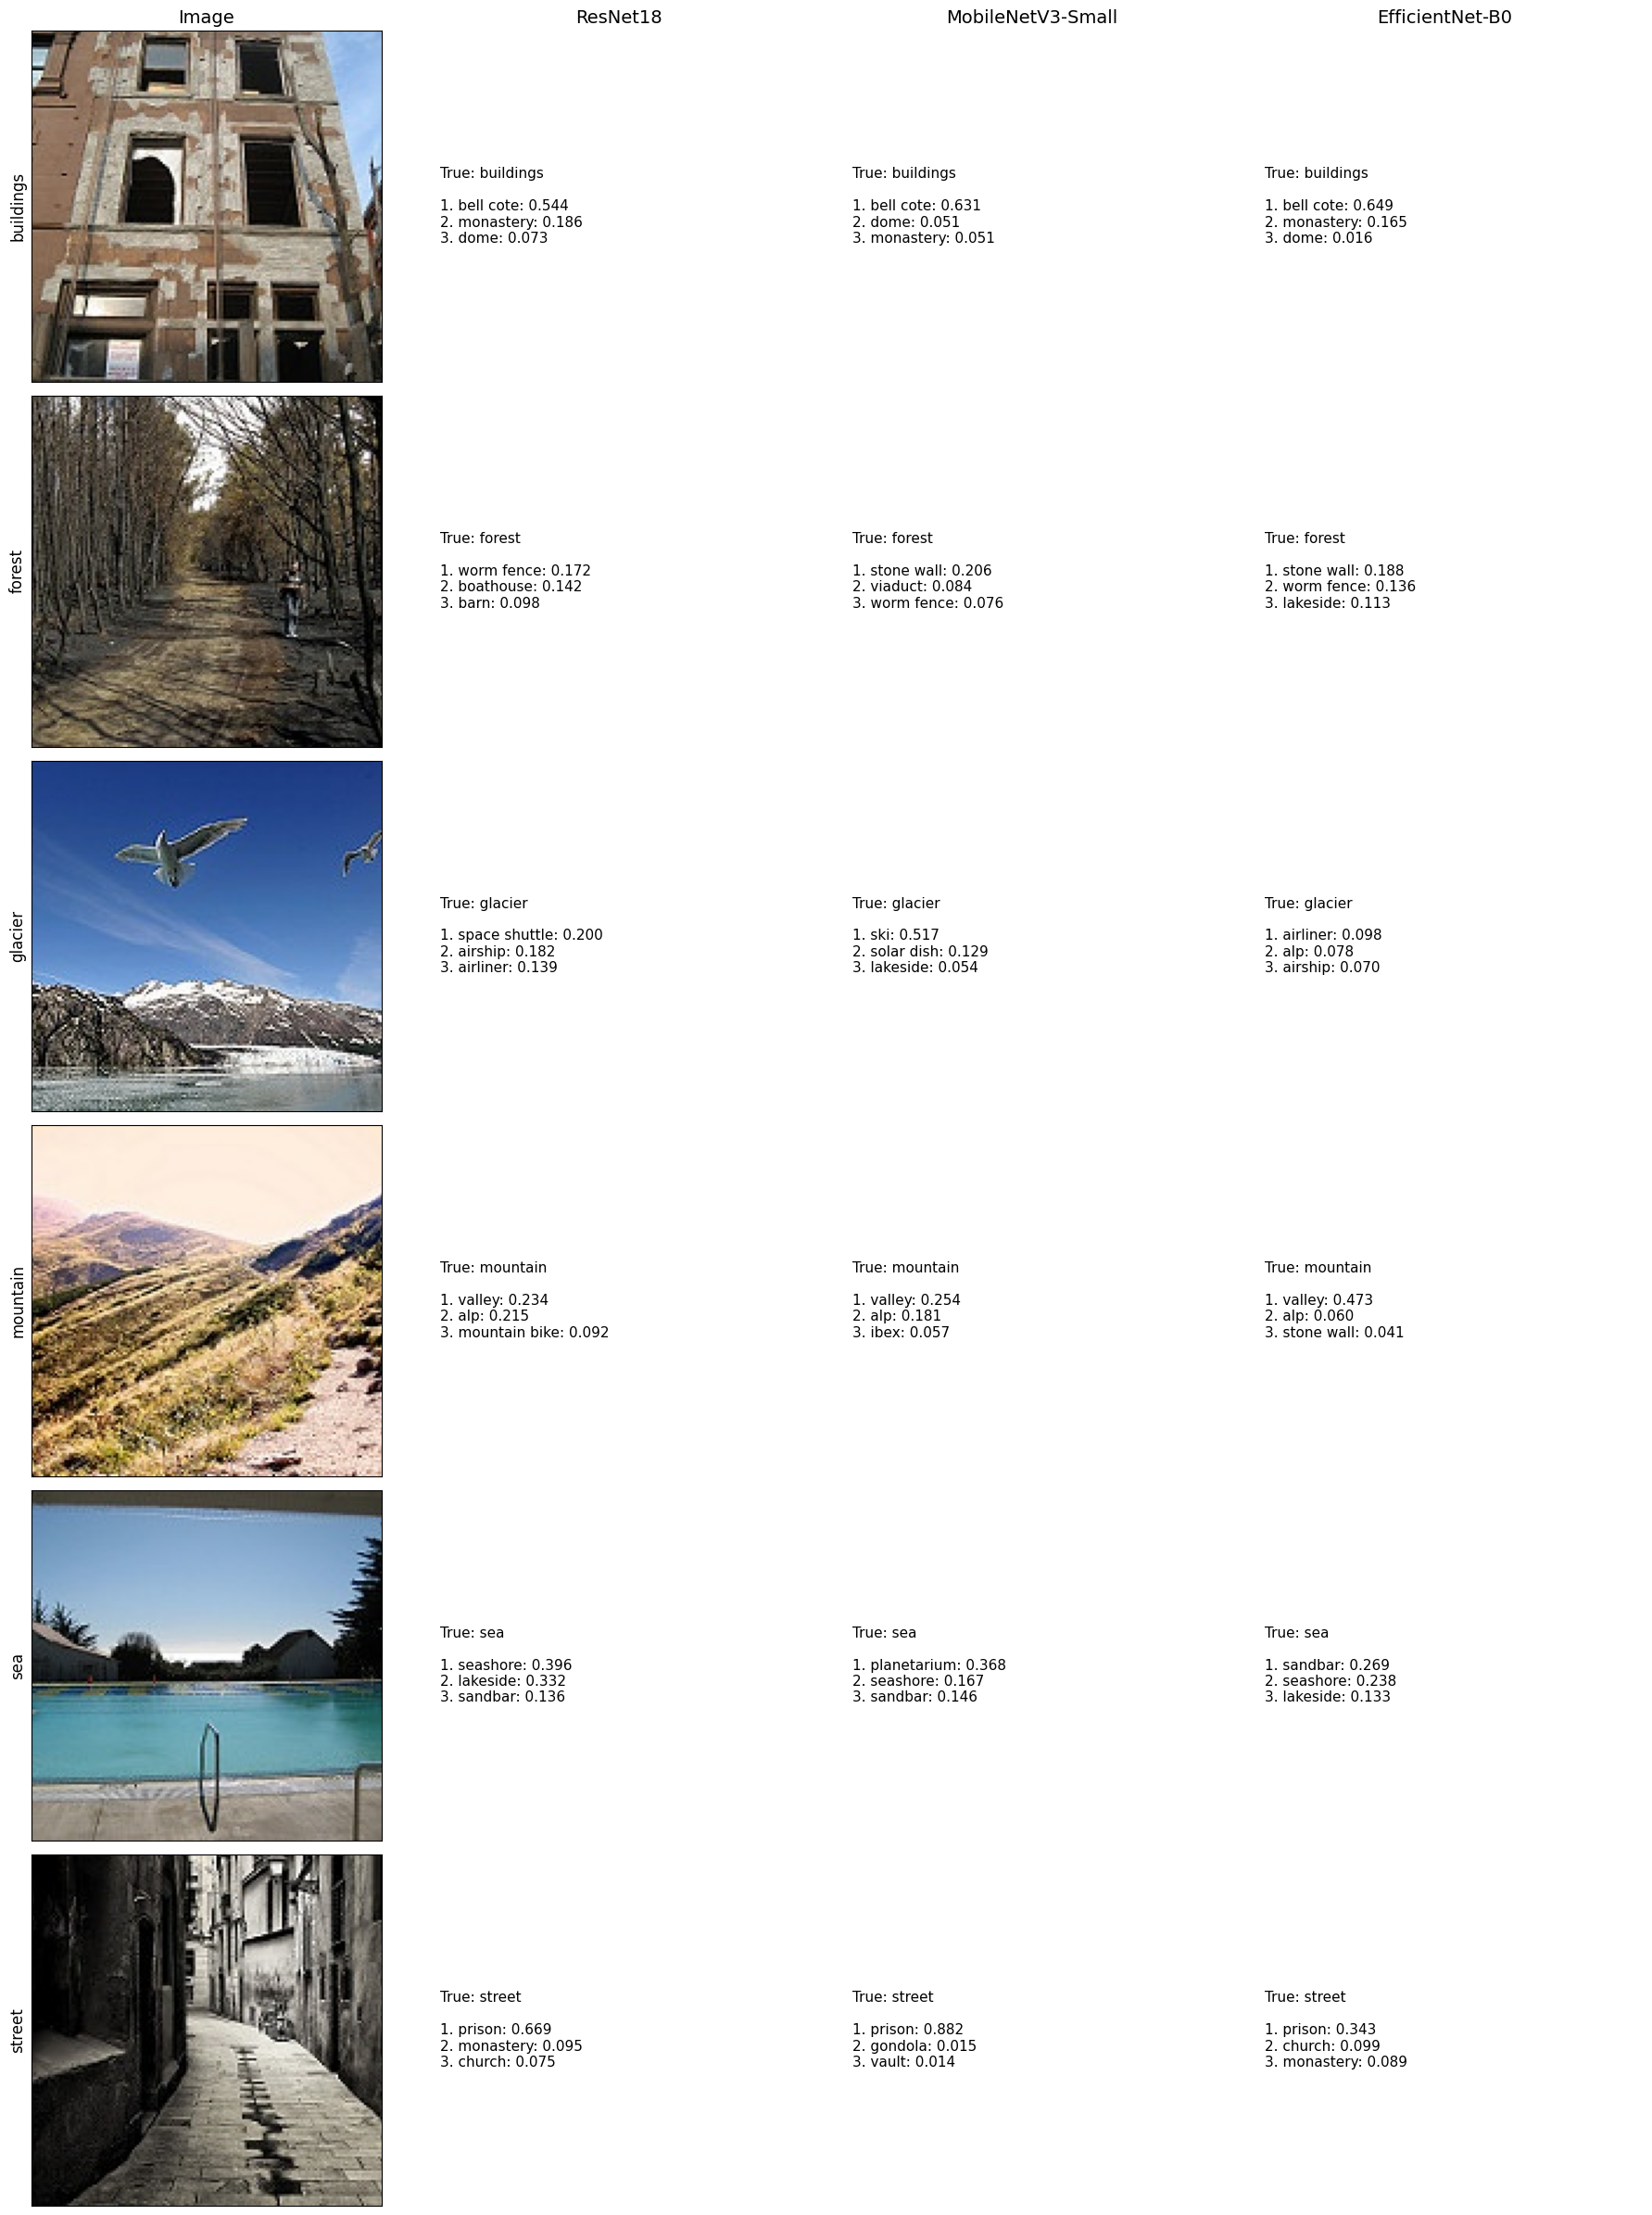

In [ ]:
# Pick one image from each class
selected_indices = []

for label in LABELS:
    idx = next(
        i for i, (_, true_label) in enumerate(image_set)
        if true_label == label
    )
    selected_indices.append(idx)

fig, axes = plt.subplots(6, 4, figsize=(18, 24))

model_names = ["Image", "ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]

for col, name in enumerate(model_names):
    axes[0, col].set_title(name, fontsize=14)

for row, idx in enumerate(selected_indices):
    img, true_label = image_set[idx]

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(true_label, fontsize=12)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    all_results = [
        resnet_results[idx],
        mobilenet_results[idx],
        effnet_results[idx],
    ]

    for col, result in enumerate(all_results, start=1):
        text_lines = [f"True: {true_label}", ""]
        for rank in range(3):
            cls = result["top5_classes"][rank]
            prob = result["top5_probs"][rank]
            text_lines.append(f"{rank + 1}. {cls}: {prob:.3f}")

        axes[row, col].text(
            0.05,
            0.5,
            "\n".join(text_lines),
            fontsize=11,
            va="center",
            ha="left"
        )
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", dpi=150)
plt.show()

The three models often produce related predictions, but they may not always agree on the exact top-1 ImageNet class. This is expected because the Intel scene labels are broad categories, while ImageNet labels are more specific and object-focused.

Significant disagreements can be useful. If one model predicts "alp", another predicts "valley", and another predicts "mountain tent", they may disagree on the exact ImageNet class but still point toward a similar outdoor scene. If their predictions differ completely, that may indicate an ambiguous or difficult image.

This suggests that an ensemble could help in some cases. Combining predictions from multiple models can make the system more stable, especially when one model makes an unusual mistake. However, ensembles also increase inference cost and latency, so they may not be ideal for mobile deployment.

For this outdoor scene dataset, the most semantically sensible model is the one whose top-5 predictions most often contain scene-relevant labels, even if the labels are not exact matches. For example, labels such as "alp", "valley", "lakeside", "seashore", "street sign", or "barn" may still be meaningful for this dataset even though they are not among the official six target labels.

# Task 4: Speed vs. Accuracy Tradeoff

In [ ]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.17 ms/image
MobileNetV3-Small:  7.19 ms/image
EfficientNet-B0:    10.63 ms/image


In [ ]:
resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

ResNet18:           4.14 ms/image
MobileNetV3-Small:  7.48 ms/image
EfficientNet-B0:    10.53 ms/image


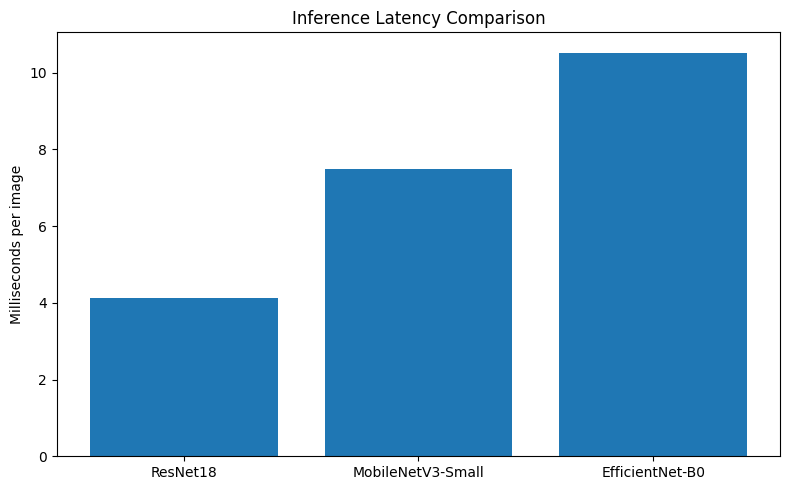

In [ ]:
models_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(models_names, latencies)
plt.ylabel("Milliseconds per image")
plt.title("Inference Latency Comparison")
plt.tight_layout()
plt.savefig("outputs/inference_speed.png", dpi=150)
plt.show()

In [ ]:
summary = [
    ("ResNet18", sum(p.numel() for p in resnet.parameters()), resnet_ms),
    ("MobileNetV3-Small", sum(p.numel() for p in mobilenet.parameters()), mobile_ms),
    ("EfficientNet-B0", sum(p.numel() for p in efficientnet.parameters()), effnet_ms),
]

print(f"{'Model':22s} {'Parameters':>15s} {'ms / image':>15s}")
print("-" * 55)

for name, params, ms in summary:
    print(f"{name:22s} {params:15,} {ms:15.2f}")

Model                       Parameters      ms / image
-------------------------------------------------------
ResNet18                    11,689,512            4.14
MobileNetV3-Small            2,542,856            7.48
EfficientNet-B0              5,288,548           10.53


To process 50 images per second, the system must handle each image in:
1000 ms / 50 = 20 ms per image.

This means the maximum tolerable latency is 20 ms/image.
Based on the benchmark results:
- Any model below 20 ms/image can meet the requirement.
- Models above that threshold are too slow for real-time use at this rate.

In practice, MobileNetV3-Small is the most likely to meet this constraint, while EfficientNet-B0 may be too slow depending on hardware.

(a) High-throughput cloud pipeline:
I would choose EfficientNet-B0. In a cloud environment, compute resources are 
less constrained, and higher accuracy is often worth the additional latency.

(b) On-device mobile app:
I would choose MobileNetV3-Small. It is designed for low latency, low power consumption, and smaller memory footprint, making it ideal for edge devices.

(c) Safety-critical quality-control system:
I would prioritize accuracy over speed and choose EfficientNet-B0. In such systems, incorrect predictions can have serious consequences, so higher model capacity and better semantic understanding are more important than latency.

# Task 5: Feature Extraction & PCA

In [ ]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each

Feature matrix shape: (60, 512)


# *1. Clustering*

If images from the same class cluster together in the 2D PCA space, it means the pretrained model has already learned useful visual representations that separate different scene types, even though it was trained on ImageNet.
This shows that the model captures general features like textures, shapes, and spatial patterns (e.g., trees vs water vs buildings), which transfer well
to new datasets.
Strong clustering suggests the features are already meaningful for this task, even before any fine-tuning.

# *2. Transfer Learning Strategy*

With only 500 labeled examples, I would start with feature extraction.
That means freezing the pretrained layers and training only a new final classification layer. This reduces the risk of overfitting because the model is not trying to update millions of parameters with limited data.
If performance is not sufficient, I could then move to fine-tuning a few of the deeper layers. But starting with feature extraction is safer and more stable when data is limited.